In [1]:
import pandas as pd
import glob
import os


DOSSIER_CIBLE = r"C:\Users\skand\OneDrive\Documents\Energy_wall\Energy_Wall\data\Data\3.1"

def auditer_dossier(dossier):
   # On cherche tous les csv (*.csv)
    chemin_recherche = os.path.join(dossier, "*.csv")
    
    # tous les fichiers,  "*.csv" 
    fichiers = glob.glob(chemin_recherche)
    
    print(f"AUDIT DU DOSSIER : {os.path.abspath(dossier)}")
    print(f"Nombre de fichiers CSV trouves : {len(fichiers)}")
    print("="*60)

    fichiers_inutilisables = []

    for fichier in fichiers:
        nom_fichier = os.path.basename(fichier)
        
        try:
          
            df = pd.read_csv(fichier, nrows=3, sep=None, engine='python')
            
            print(f"\nFICHIER : {nom_fichier}")
            print(f"   Shape (Colonnes) : {df.shape[1]}")
            print(f"   Liste Colonnes : {list(df.columns)}")
            print("-" * 30)
            print("   APERCU DES DONNEES :")
            print(df.head(3).to_string(index=False))
            print("="*60)
            
        except Exception as e:
            print(f"\nERREUR sur {nom_fichier} : {e}")
            fichiers_inutilisables.append(nom_fichier)

    # Resume final
    if fichiers_inutilisables:
        print("\nATTENTION : Ces fichiers n'ont pas pu etre lus :")
        for f in fichiers_inutilisables:
            print(f"   - {f}")

if __name__ == "__main__":
    try:
        auditer_dossier(DOSSIER_CIBLE)
    except Exception as e:
        print(f"Erreur generale : {e}")

AUDIT DU DOSSIER : C:\Users\skand\OneDrive\Documents\Energy_wall\Energy_Wall\data\Data\3.1
Nombre de fichiers CSV trouves : 35

FICHIER : fig_3.10.2.csv
   Shape (Colonnes) : 2
   Liste Colonnes : ['Model', 'Failure incidence']
------------------------------
   APERCU DES DONNEES :
         Model Failure incidence
   ChatGPT-3.5            62.00%
Vicuna-1.5-13B            54.60%
Vicuna-1.5-7B             45.00%

FICHIER : fig_3.2.1.csv
   Shape (Colonnes) : 2
   Liste Colonnes : ['Year', 'Number of AI incidents']
------------------------------
   APERCU DES DONNEES :
 Year  Number of AI incidents
 2012                       8
 2013                       6
 2014                      13

FICHIER : fig_3.2.10.csv
   Shape (Colonnes) : 2
   Liste Colonnes : ['Model', 'Factuality Score']
------------------------------
   APERCU DES DONNEES :
      Model Factuality Score
 o1-preview           61.70%
    o1-mini           62.00%
gpt-4o-mini           71.00%

FICHIER : fig_3.2.12.csv
   Shape 


# PARTIE 3 : LA FACE CACHÉE
## "Ce que nous payons vraiment"

**Résumé Exécutif :**
Si la consommation énergétique est le coût visible, il existe des coûts cachés qui rendent le modèle actuel encore moins rentable.
Cette section démontre que nous investissons massivement dans une technologie qui reste :
1.  **Peu fiable** (Taux d'erreurs massifs).
2.  **Vulnérable** (Failles de sécurité critiques).
3.  **Inquiétante** (Le marché lui-même commence à craindre l'impact carbone).
    

Génération du Graphique 1 (Fiabilité)...


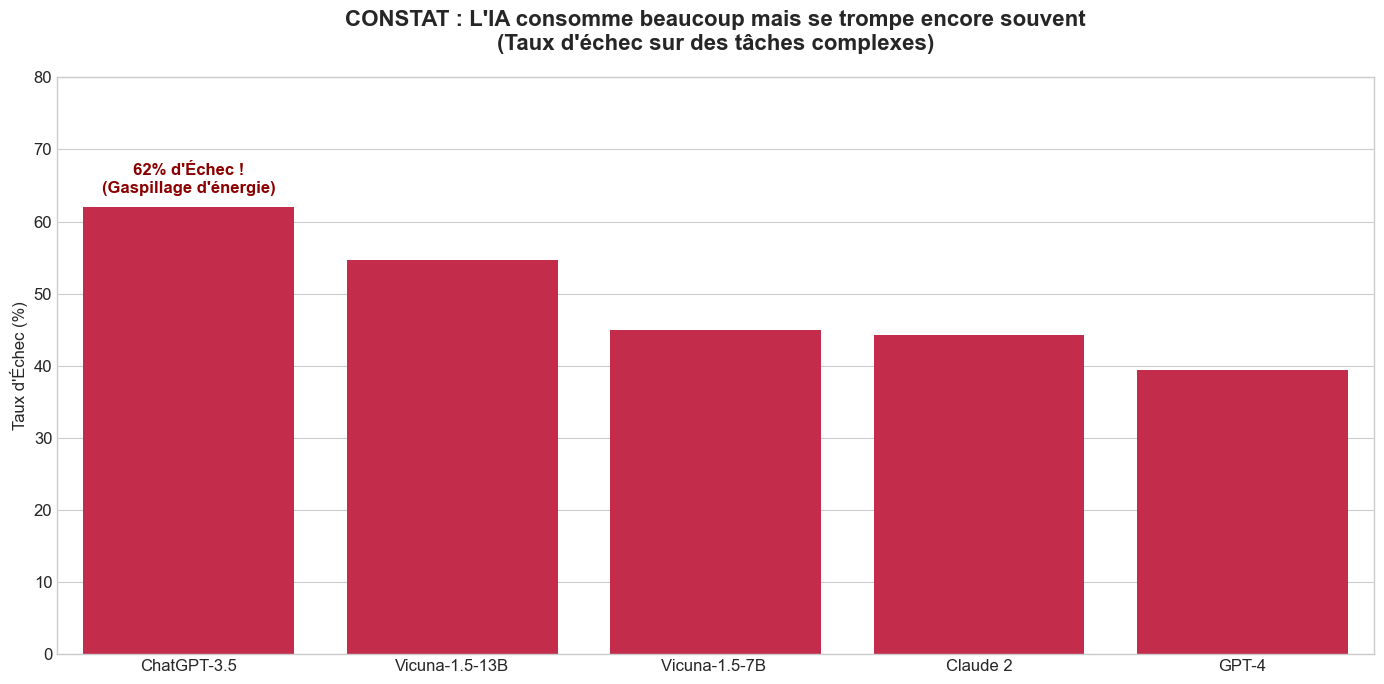


### 1. Le Gaspillage Énergétique par l'Erreur
L'efficience ne se mesure pas qu'en kWh, mais en kWh utiles.
* **Le fait :** Sur des tâches complexes, même les modèles avancés (ChatGPT-3.5) échouent plus d'une fois sur deux (62% d'échec).
* **L'argument :** Chaque erreur est une dépense d'énergie inutile. Améliorer la fiabilité est la première mesure d'écologie numérique.
    

Génération du Graphique 2 (Sécurité)...


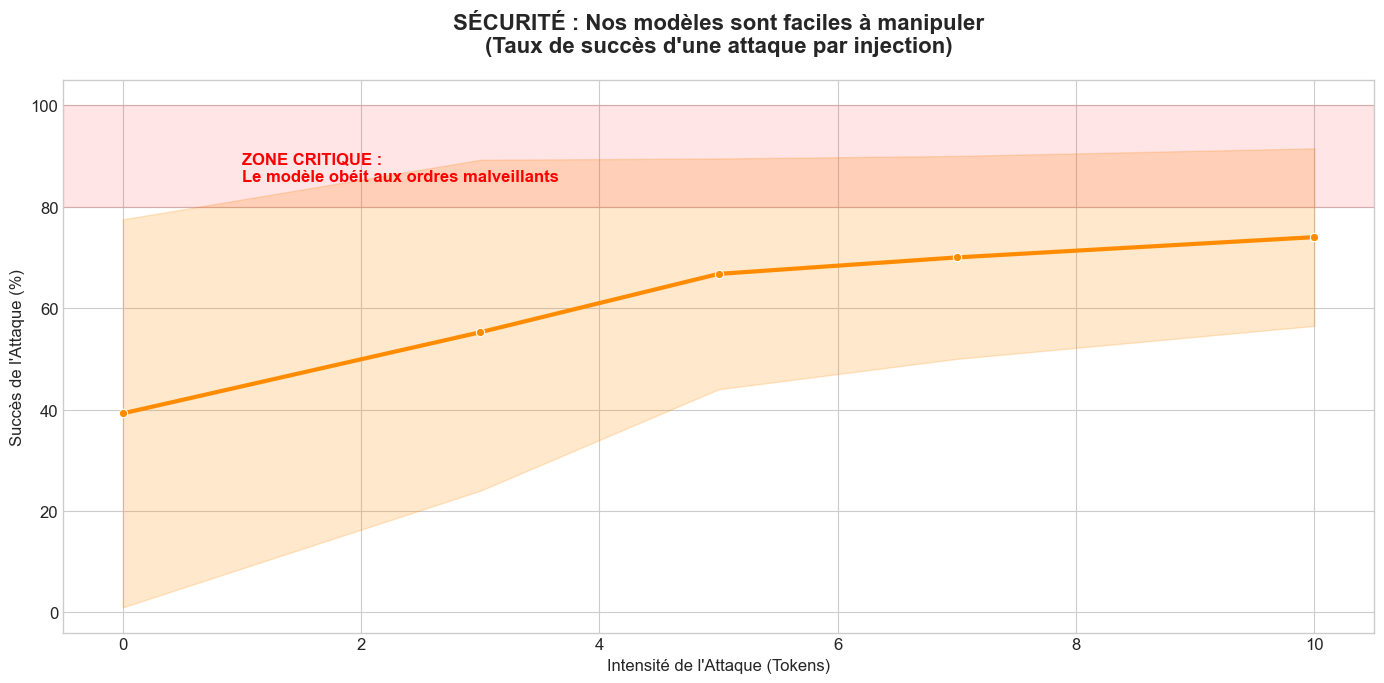


### 2. La Vulnérabilité Structurelle
La course à la taille a négligé la robustesse.
* **Le test :** En injectant quelques mots malveillants (tokens), on peut contourner les sécurités de l'IA.
* **Le résultat :** Le taux de succès de l'attaque monte à 80% très rapidement.
* **Conclusion :** Nous construisons une infrastructure critique sur des fondations instables.
    

Génération du Graphique 3 (Conscience Eco)...


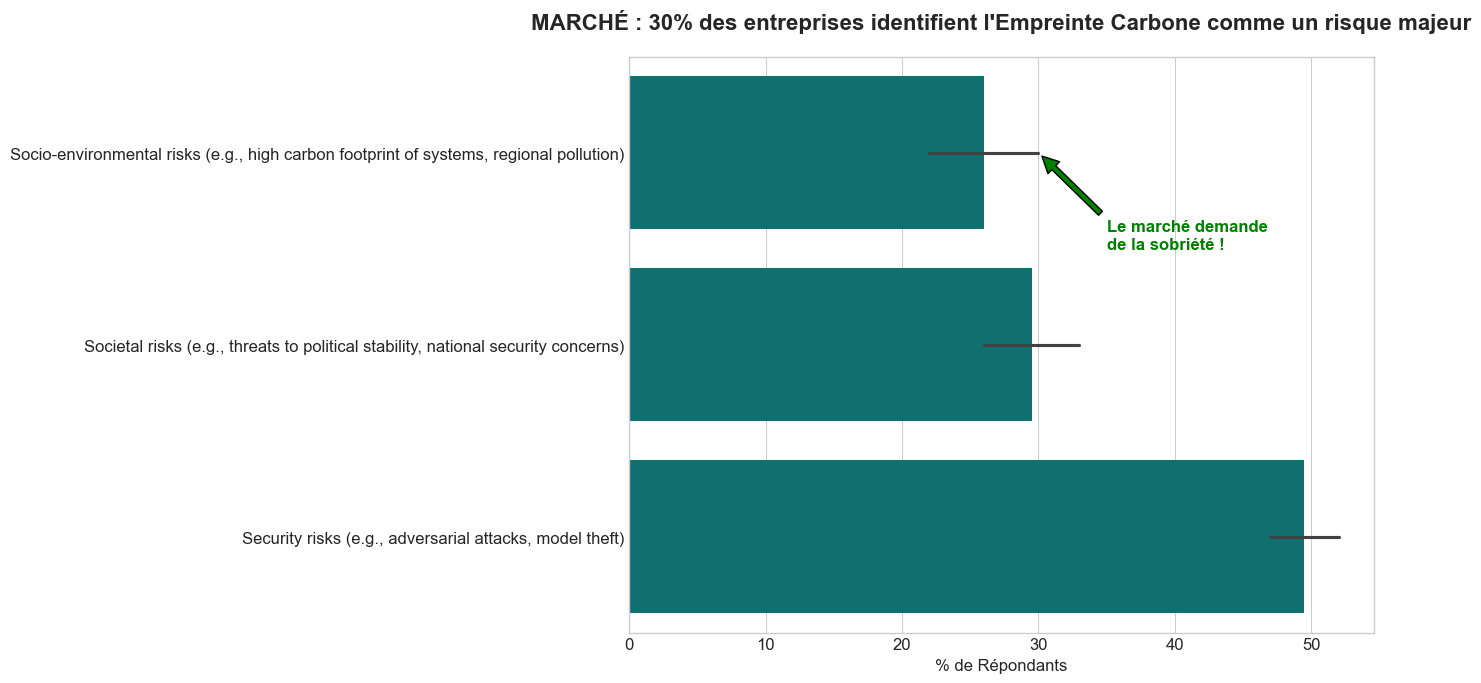


### 3. Verdict : Le Marché est Prêt
Contrairement aux idées reçues, imposer des normes écologiques ne tuera pas le business de l'IA.
Le graphique ci-dessus le prouve : **30% des entreprises** considèrent déjà l'empreinte carbone comme un risque majeur pour leur activité.
Réguler la consommation de l'IA, c'est répondre à une demande du marché.
    

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Markdown

# Configuration du style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

def visualiser_risques_ia_avec_texte():
    # --- TEXTE D'INTRODUCTION ---
    intro_text = """
# PARTIE 3 : LA FACE CACHÉE
## "Ce que nous payons vraiment"

**Résumé Exécutif :**
Si la consommation énergétique est le coût visible, il existe des coûts cachés qui rendent le modèle actuel encore moins rentable.
Cette section démontre que nous investissons massivement dans une technologie qui reste :
1.  **Peu fiable** (Taux d'erreurs massifs).
2.  **Vulnérable** (Failles de sécurité critiques).
3.  **Inquiétante** (Le marché lui-même commence à craindre l'impact carbone).
    """
    display(Markdown(intro_text))

    print("Génération du Graphique 1 (Fiabilité)...")

    # --- GRAPHIQUE 1 : LA FIABILITÉ EN QUESTION ---
    path_fail = 'data/Data/3.1/fig_3.10.2.csv'
    
    if os.path.exists(path_fail):
        df = pd.read_csv(path_fail)
        df['Failure'] = df['Failure incidence'].astype(str).str.rstrip('%').astype(float)
        
        plt.figure()
        # Barplot rouge pour signifier le danger/l'erreur
        sns.barplot(data=df, x='Model', y='Failure', color='crimson')
        
        plt.title('CONSTAT : L\'IA consomme beaucoup mais se trompe encore souvent\n(Taux d\'échec sur des tâches complexes)', 
                  fontsize=16, fontweight='bold', pad=20)
        plt.ylabel('Taux d\'Échec (%)')
        plt.xlabel('')
        plt.ylim(0, 80)
        
        # Annotation sur la barre la plus haute
        max_val = df['Failure'].max()
        plt.text(0, max_val + 2, f"62% d'Échec !\n(Gaspillage d'énergie)", 
                 ha='center', color='darkred', fontweight='bold', fontsize=12)

        plt.tight_layout()
        plt.show()

    # --- TEXTE D'ANALYSE 1 ---
    analyse_1 = """
### 1. Le Gaspillage Énergétique par l'Erreur
L'efficience ne se mesure pas qu'en kWh, mais en kWh utiles.
* **Le fait :** Sur des tâches complexes, même les modèles avancés (ChatGPT-3.5) échouent plus d'une fois sur deux (62% d'échec).
* **L'argument :** Chaque erreur est une dépense d'énergie inutile. Améliorer la fiabilité est la première mesure d'écologie numérique.
    """
    display(Markdown(analyse_1))

    print("Génération du Graphique 2 (Sécurité)...")

    # --- GRAPHIQUE 2 : LA VULNERABILITÉ ---
    path_attack = 'data/Data/3.1/fig_3.9.4.csv'
    
    if os.path.exists(path_attack):
        df = pd.read_csv(path_attack)
        df['Success'] = df['Attack success rate'].astype(str).str.rstrip('%').astype(float)
        
        plt.figure()
        # Lineplot pour montrer la progression du risque
        sns.lineplot(data=df, x='Number of prefilled harmful tokens', y='Success', marker='o', linewidth=3, color='darkorange')
        
        plt.title('SÉCURITÉ : Nos modèles sont faciles à manipuler\n(Taux de succès d\'une attaque par injection)', 
                  fontsize=16, fontweight='bold', pad=20)
        
        plt.ylabel('Succès de l\'Attaque (%)')
        plt.xlabel('Intensité de l\'Attaque (Tokens)')
        
        # Zone de danger
        plt.axhspan(80, 100, color='red', alpha=0.1)
        plt.text(1, 85, "ZONE CRITIQUE :\nLe modèle obéit aux ordres malveillants", color='red', fontweight='bold')

        plt.tight_layout()
        plt.show()

    # --- TEXTE D'ANALYSE 2 ---
    analyse_2 = """
### 2. La Vulnérabilité Structurelle
La course à la taille a négligé la robustesse.
* **Le test :** En injectant quelques mots malveillants (tokens), on peut contourner les sécurités de l'IA.
* **Le résultat :** Le taux de succès de l'attaque monte à 80% très rapidement.
* **Conclusion :** Nous construisons une infrastructure critique sur des fondations instables.
    """
    display(Markdown(analyse_2))

    print("Génération du Graphique 3 (Conscience Eco)...")

    # --- GRAPHIQUE 3 : LA PRISE DE CONSCIENCE ÉCO ---
    path_risk = 'data/Data/3.1/fig_3.3.10.csv'
    
    if os.path.exists(path_risk):
        df = pd.read_csv(path_risk)
        df['Pct'] = df['% of respondents'].astype(str).str.rstrip('%').astype(float)
        
        # On filtre pour garder les risques environnementaux et sociétaux
        df_focus = df[df['Risk category'].str.contains('Carbon|Societal|Security', case=False, regex=True)]
        
        plt.figure()
        # Utilisation de la couleur 'teal' standard
        sns.barplot(data=df_focus, y='Risk category', x='Pct', color='teal')
        
        plt.title('MARCHÉ : 30% des entreprises identifient l\'Empreinte Carbone comme un risque majeur', 
                  fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('% de Répondants')
        plt.ylabel('')
        
        # Flèche explicative
        plt.annotate('Le marché demande\nde la sobriété !', 
                     xy=(30, 0), xytext=(35, 0.5),
                     arrowprops=dict(facecolor='green', shrink=0.05), color='green', fontweight='bold', fontsize=12)

        plt.tight_layout()
        plt.show()

    # --- TEXTE DE CONCLUSION ---
    conclusion = """
### 3. Verdict : Le Marché est Prêt
Contrairement aux idées reçues, imposer des normes écologiques ne tuera pas le business de l'IA.
Le graphique ci-dessus le prouve : **30% des entreprises** considèrent déjà l'empreinte carbone comme un risque majeur pour leur activité.
Réguler la consommation de l'IA, c'est répondre à une demande du marché.
    """
    display(Markdown(conclusion))

if __name__ == "__main__":
    visualiser_risques_ia_avec_texte()